## Deconvolution using geneformer (bulk + single-cell reference)
This tutorial demonstrates how to run bulk RNA-seq deconvolution using DECONVersation's built-in functions with Geneformer embeddings, though the workflow is fully adaptable to Cell2Sentence or CellHermes. The tutorial covers the full pipeline: extracting Geneformer embeddings from both bulk and single-cell reference datasets, constructing signature matrices from the single-cell embeddings, and estimating cell type proportions via NNLS. Finally, predicted proportions are evaluated against ground truth using RMSE and Pearson correlation to assess deconvolution performance. <br>

### Step 0: Load reference data (scRNA-seq)

In [1]:
# Append path to deconversation modules
import sys
import os
import scanpy as sc
sys.path.append('../deconversation')

In [2]:
# Import associated modules
from pseudobulk import *
from preprocessing import *

In [3]:
# Path to single-cell RNAseq data 
path = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/geneformer/complete/haoSub.h5ad"

### Step 1: Prep data for geneformer

Load data uing scanpy and prep data for geneformer. `load_and_prep_data()` prepares the loaded anndata for geneformer by populating expected variables required by geneformer architecture.  Here we pass `mode = "geneformer"` since this is a geneformer based tutorial. However, if using cell2setence pass `mode = "c2s"`.

In [4]:
# Read the h5ad file (just to explore columns and variables)
adata = sc.read_h5ad(path)

adata = adata[adata.obs["broad_type"].isin(
    ['B cells', 'Monocytes', 'NK cells', 'T cells', 'mDC', 'pDC']
)]

# Remove unmapped genes
adata = adata[:, adata.var.index.notnull()]

# Prep data for geneformer
adata = load_and_prep_data(adata= adata, cell_type_col= "broad_type", mode="geneformer")

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/../deconversation/preprocessing.py:50: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["cell_id"] = adata.obs.index


### Step 2: Load bulk data

In [5]:
# Read in bulk RNAseq data
hoek_bulk = pd.read_csv("/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/bulk/hoek/hoek_counts.csv",
                       index_col=0)

# Map genes to ensembl id (required for geneformer)
hoek_bulk.index = gene_id_name_map(gene_list=hoek_bulk.index, mode="to_ensembl" )

# Drop unmapped genes 
hoek_bulk = hoek_bulk.loc[hoek_bulk.index.dropna()]

### Step 3: Create signature matrix

In [6]:
sig_mat = create_signature_matrix(adata = adata,
                                     sample_col = "batch", # sample id column
                                     cell_type_col = "broad_type",
                                     groupby = "broad_type",
                                     output_path = None)

# Transpose for embedding extraction
# Columns should be gene names or ensembl ids (ensembl ids for geneformer)
sig_mat = sig_mat.T

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/../deconversation/preprocessing.py:256: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  signature = expr.groupby(groupby).mean().T


The signature matrix is constructed by averaging gene expression across the selected cell types, requiring no predefined gene markers. To build a signature matrix from a specific subset of samples, pass the desired sample IDs as a list. Here, all available samples are used, so `sample_id` is set to None.

### Step 4: Extract Embeddings

### Geneformer

In [2]:
from embeddings import *
from deconvolution import *

geneformer successfully imported.
cell2sentence is not installed. Skipping related functions.
cellhermes is not installed. Skipping related functions.
scGPT is not installed. Skipping related functions.
scVI successfully imported.


In [8]:
# # Extract geneformer embeddings for signature matrix
# sig_mat_gf_embed = extract_embs(
#     bulk_df = sig_mat_gf,
#     mode = "geneformer",
#     temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
#     model_path= "ctheodoris/Geneformer",
#     delete_temp_files = True
# )

In [9]:
# # Extract geneformer embeddings for signature matrix
# gf_embed = extract_embs(
#     bulk_df = hoek_bulk.T, # sample x ensembl id
#     mode = "geneformer",
#     temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
#     model_path= "ctheodoris/Geneformer",  # Default geneformer model
#     delete_temp_files = True # if True, delete all temporary files created whiile extracting embeddings
# )

### PCA

In [10]:
# Extract embeddings 
bulk_sig_mat_pc = extract_components(bulk_df = hoek_bulk.T,
                                     sig_mat = sig_mat,
                                     mode = "pca",
                                     transform = True)

bulk_pc = bulk_sig_mat_pc["pca_bulk"]
sig_mat_pc = bulk_sig_mat_pc["sig_pca"]

Variance explained by 6 PCs: 100.00%


In [11]:
# Run NNLS
cell_prop_pred = run_deconv(bulk_df = bulk_pc.T, 
                            signature_df = sig_mat_pc.T, 
                            normalize = True)

Using 6 common features.
Running deconvolution...


In [13]:
results = run_all_deconv(bulk_df=bulk_pc.T, 
                         signature_df=sig_mat_pc.T)

Using 6 common features.
Running deconvolution...
Using 6 common features.
Running deconvolution...
Using 6 common features.
Running deconvolution...
Using 6 common features.
Running deconvolution...
Using 6 common features.
Running deconvolution...
Using 6 common features.
Running deconvolution...
Using 6 common features.
Running deconvolution...
Using 6 common features.
Running deconvolution...
Using 6 common features.
Running deconvolution...


In [47]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def plot_solver_benchmarks(
    results, ground_truth, return_tables=False, save_prefix=None
):
    def _safe_corr(a, b):
        if np.std(a) == 0 or np.std(b) == 0:
            return np.nan
        return np.corrcoef(a, b)[0, 1]

    global_rows, celltype_rows = [], []
    for solver, pred in results.items():
        samples = pred.index.intersection(ground_truth.index)
        celltypes = pred.columns.intersection(ground_truth.columns)
        if len(samples) == 0 or len(celltypes) == 0:
            print(f"[skipped] {solver}: no overlapping samples/cell types")
            continue

        p = pred.loc[samples, celltypes]
        g = ground_truth.loc[samples, celltypes]

        pv, gv = p.values.ravel(), g.values.ravel()
        global_rows.append(
            {
                "Model": solver,
                "Correlation": _safe_corr(pv, gv),
                "RMSE": np.sqrt(np.mean((pv - gv) ** 2)),
            }
        )

        for ct in celltypes:
            pc, gc = p[ct].values, g[ct].values
            celltype_rows.append(
                {
                    "Model": solver,
                    "CellType": ct,
                    "Correlation": _safe_corr(pc, gc),
                    "RMSE": np.sqrt(np.mean((pc - gc) ** 2)),
                }
            )

    global_df = pd.DataFrame(global_rows)
    celltype_df = pd.DataFrame(celltype_rows)

    data_sorted = celltype_df.sort_values(
        by=["CellType", "Correlation"], ascending=[True, False]
    )
    model_order = list(dict.fromkeys(data_sorted["Model"].tolist()))
    sorted_cell_types = (
        celltype_df.groupby("CellType")["Correlation"]
        .mean()
        .sort_values(ascending=False)
        .index
    )

    pivot_corr = (
        celltype_df.pivot(index="Model", columns="CellType", values="Correlation")
        .reindex(model_order)[sorted_cell_types]
    )
    pivot_rmse = (
        celltype_df.pivot(index="Model", columns="CellType", values="RMSE")
        .reindex(model_order)[sorted_cell_types]
    )

    sns.set_theme(style="white")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(
        pivot_corr,
        annot=True,
        cmap="viridis",
        fmt=".2f",
        linewidths=0.5,
        cbar_kws={"label": "Correlation (Higher is Better)"},
        ax=axes[0],
    )
    axes[0].set_title("Correlation", pad=12, weight="bold", fontsize=13)
    axes[0].set_xlabel("Cell Type", labelpad=10)
    axes[0].set_ylabel("Model", labelpad=10)

    sns.heatmap(
        pivot_rmse,
        annot=True,
        cmap="plasma",
        fmt=".3f",
        linewidths=0.5,
        cbar_kws={"label": "RMSE (Lower is Better)"},
        ax=axes[1],
    )
    axes[1].set_title("RMSE", pad=12, weight="bold", fontsize=13)
    axes[1].set_xlabel("Cell Type", labelpad=10)
    axes[1].set_ylabel("")

    plt.tight_layout()
    if save_prefix:
        plt.savefig(f"{save_prefix}_celltype.png", dpi=300, bbox_inches="tight")
    plt.show()

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    corr_sorted = global_df.sort_values(by="Correlation", ascending=False)
    sns.barplot(
        data=corr_sorted,
        y="Model",
        x="Correlation",
        hue="Correlation",
        palette="viridis",
        dodge=False,
        legend=False,
        ax=axes[0],
    )
    axes[0].set_title(
        "Global Correlation (Higher is Better)", pad=12, weight="bold", fontsize=12
    )
    axes[0].set_xlabel("Correlation")
    axes[0].set_ylabel("Model")
    sns.despine(ax=axes[0], left=True, bottom=True)

    rmse_sorted = global_df.sort_values(by="RMSE", ascending=True)
    sns.barplot(
        data=rmse_sorted,
        y="Model",
        x="RMSE",
        hue="RMSE",
        palette="plasma_r",
        dodge=False,
        legend=False,
        ax=axes[1],
    )
    axes[1].set_title(
        "Global RMSE (Lower is Better)", pad=12, weight="bold", fontsize=12
    )
    axes[1].set_xlabel("RMSE")
    axes[1].set_ylabel("")
    sns.despine(ax=axes[1], left=True, bottom=True)

    plt.tight_layout()
    if save_prefix:
        plt.savefig(f"{save_prefix}_global.png", dpi=300, bbox_inches="tight")
    plt.show()

    if return_tables:
        return global_df, celltype_df

In [48]:
ground_truth = pd.read_csv("/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/bulk/hoek/hoek_facs.csv",
                          index_col=0)

ground_truth = ground_truth.T
ground_truth.head()

,T cell,Monocytes,B cells,mDC,NK cells
HD30_PBMC_0,0.514,0.155,0.043,0.0264,0.178
HD30_PBMC_1,0.457,0.214,0.048,0.0251,0.168
HD30_PBMC_3,0.580,0.153,0.042,0.0172,0.148
HD30_PBMC_7,0.578,0.135,0.066,0.0184,0.132
HD31_PBMC_0,0.590,0.181,0.091,0.0163,0.045


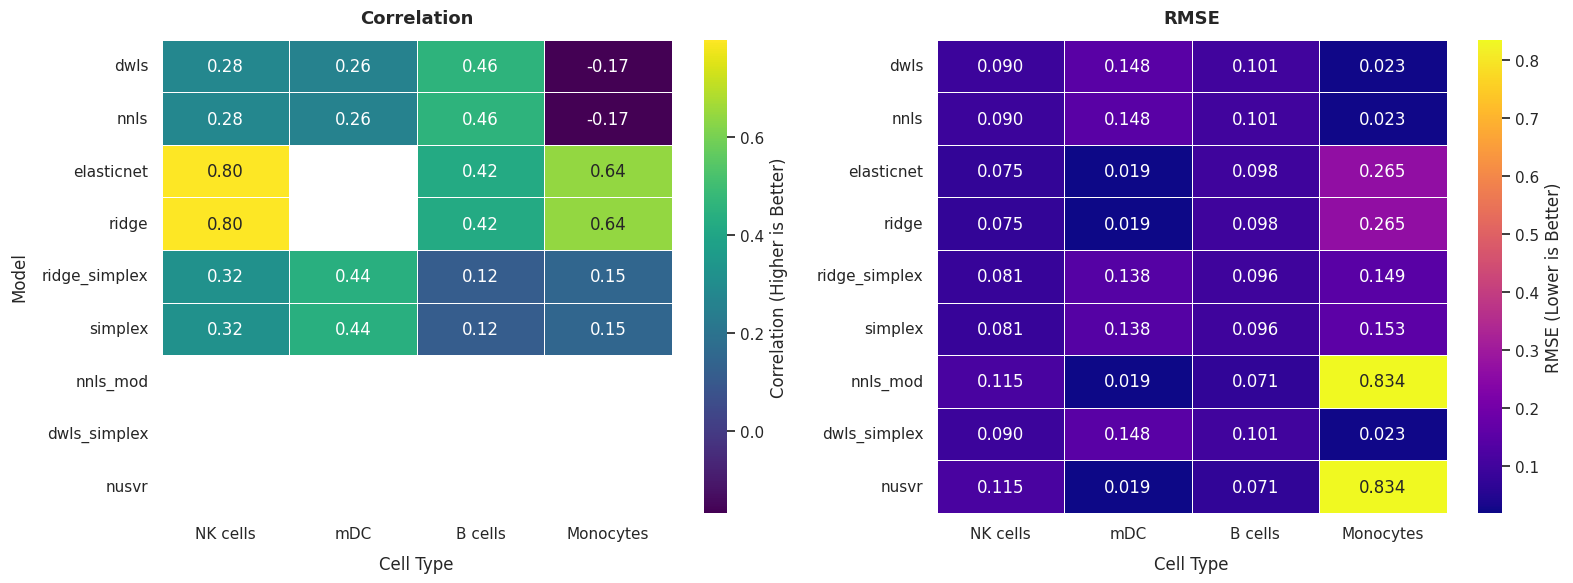

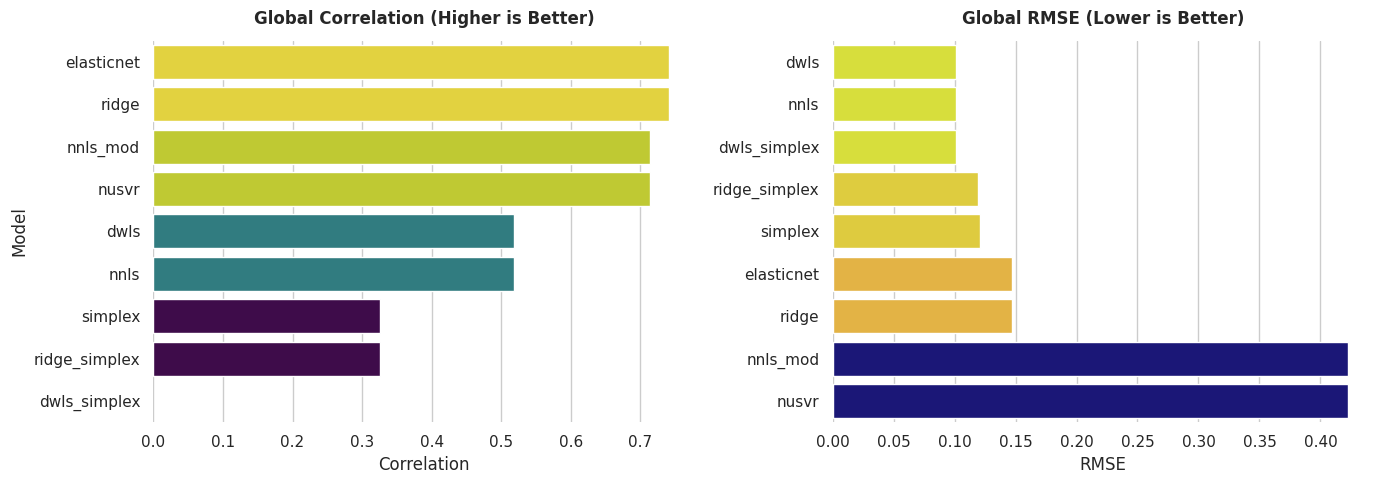

In [50]:
plot_solver_benchmarks(results, ground_truth)

### scVI

In [51]:
sig_mat_scvi_embed = extract_embs(
    bulk_df = sig_mat, # sample x ensembl id
    mode = "scvi", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01", 
    delete_temp_files = True
)

INFO     File /gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01/model.pt already downloaded  


/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:812: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['B cells', 'Monocytes', 'NK cells', 'T cells', 'mDC']

    Inferred to be: categorical

  names = self._prep_dim_index(names, "obs")


INFO     Found 44.262499999999996% reference vars in query data.                                                   
INFO     File /gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01/model.pt already downloaded  


/nfs/home/aoku/.local/lib/python3.10/site-packages/scvi/model/base/_archesmixin.py:299: UserWarning: Query data contains less than 80% of reference var names. This may result in poor performance.
  return _pad_and_sort_query_anndata(adata, var_names, inplace)
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:812: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['B cells', 'Monocytes', 'NK cells', 'T cells', 'mDC']

    Inferred to be: categorical

  names = self._prep_dim_index(names, "obs")
/nfs/home/aoku/.local/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /nfs/home/aoku/.local/lib/python3.10/site-packages/i ...
/nfs/home/aoku/.local/lib/python3.10/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: 

In [52]:
bulk_scVI = extract_embs(
    bulk_df = hoek_bulk.T, # sample x ensembl id
    mode = "scvi", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01", 
    delete_temp_files = True
)

INFO     File /gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01/model.pt already downloaded  
INFO     Found 42.475% reference vars in query data.                                                               
INFO     File /gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01/model.pt already downloaded  


/nfs/home/aoku/.local/lib/python3.10/site-packages/scvi/model/base/_archesmixin.py:299: UserWarning: Query data contains less than 80% of reference var names. This may result in poor performance.
  return _pad_and_sort_query_anndata(adata, var_names, inplace)
/nfs/home/aoku/.local/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /nfs/home/aoku/.local/lib/python3.10/site-packages/i ...


In [53]:
results = run_all_deconv(bulk_df=bulk_scVI.T, 
                         signature_df=sig_mat_scvi_embed.T)

Using 50 common features.
Running deconvolution...
Using 50 common features.
Running deconvolution...
Using 50 common features.
Running deconvolution...
Using 50 common features.
Running deconvolution...
Using 50 common features.
Running deconvolution...
Using 50 common features.
Running deconvolution...
Using 50 common features.
Running deconvolution...
Using 50 common features.
Running deconvolution...
Using 50 common features.
Running deconvolution...


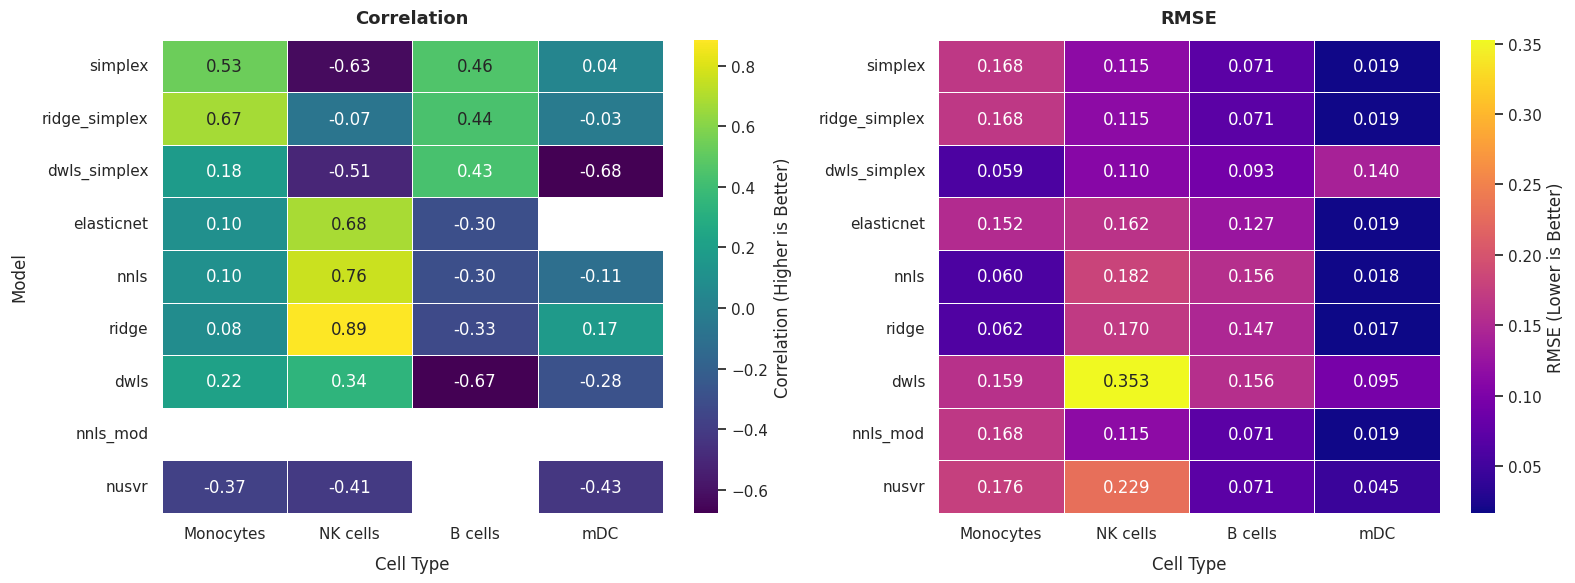

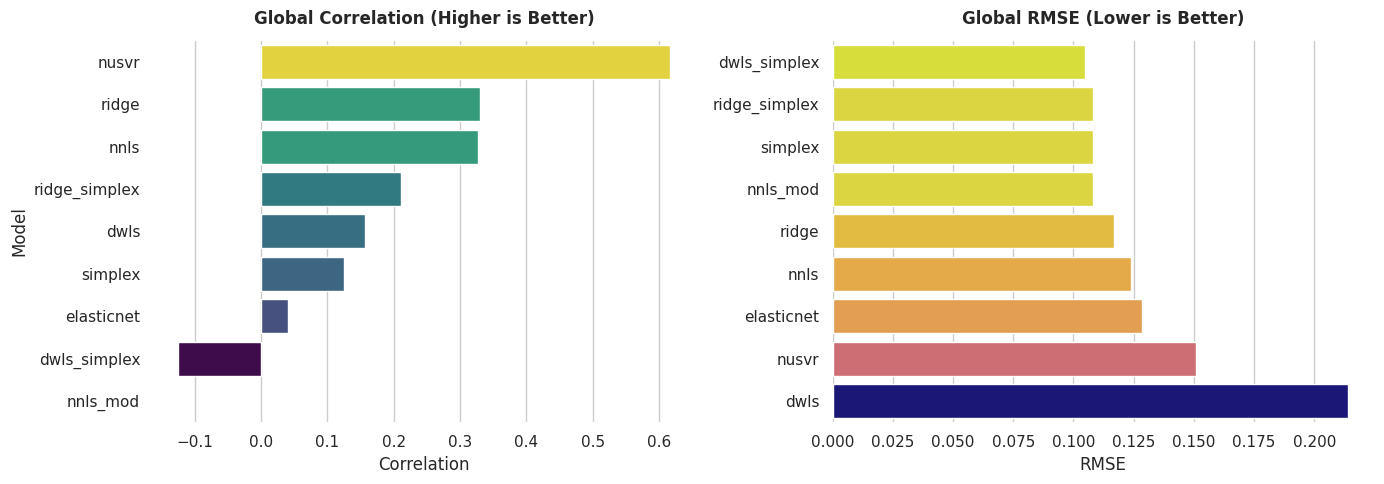

In [54]:
plot_solver_benchmarks(results, ground_truth)

### Counts

In [69]:
# Run NNLS
cell_prop_pred = run_deconv(bulk_df = hoek_bulk,
                            signature_df = sig_mat.T,
                            normalize = True)

Using 15321 common features.
Running deconvolution...


In [71]:
results = run_all_deconv(bulk_df=hoek_bulk, 
                         signature_df=sig_mat.T)

Using 15321 common features.
Running deconvolution...
Using 15321 common features.
Running deconvolution...
Using 15321 common features.
Running deconvolution...
Using 15321 common features.
Running deconvolution...
Using 15321 common features.
Running deconvolution...
Using 15321 common features.
Running deconvolution...
Using 15321 common features.
Running deconvolution...
Using 15321 common features.
Running deconvolution...
Using 15321 common features.
Running deconvolution...


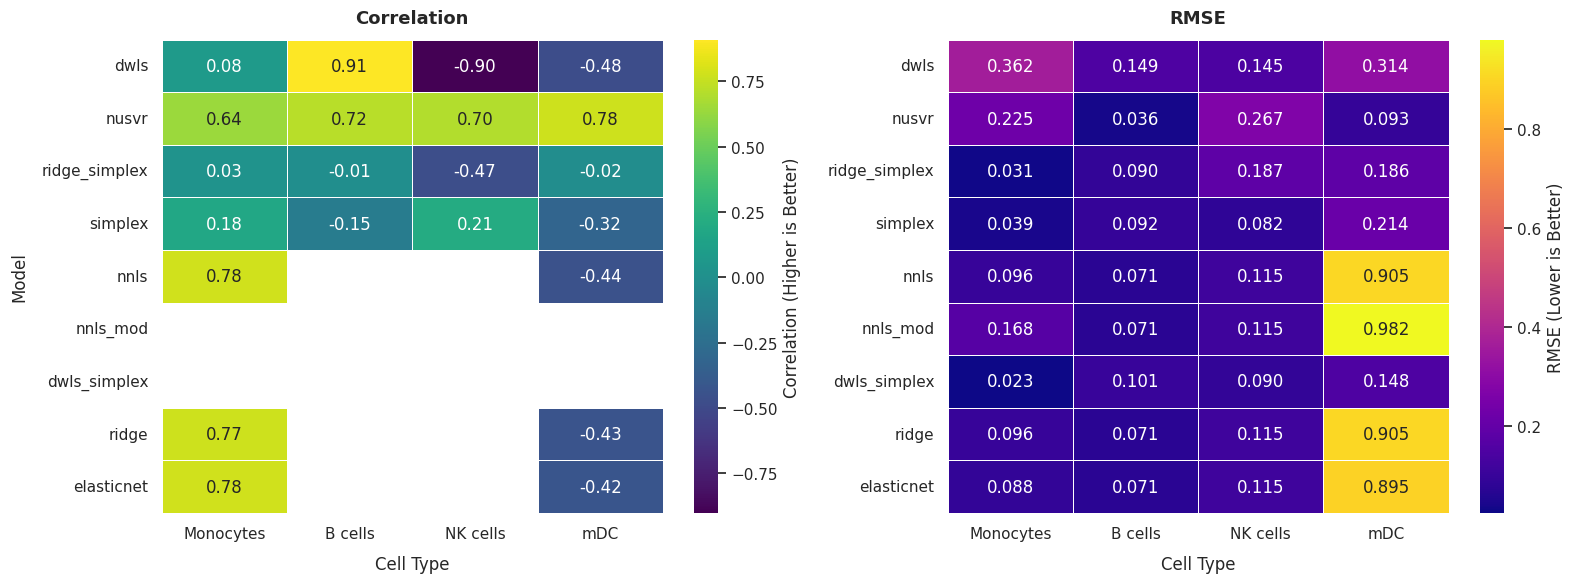

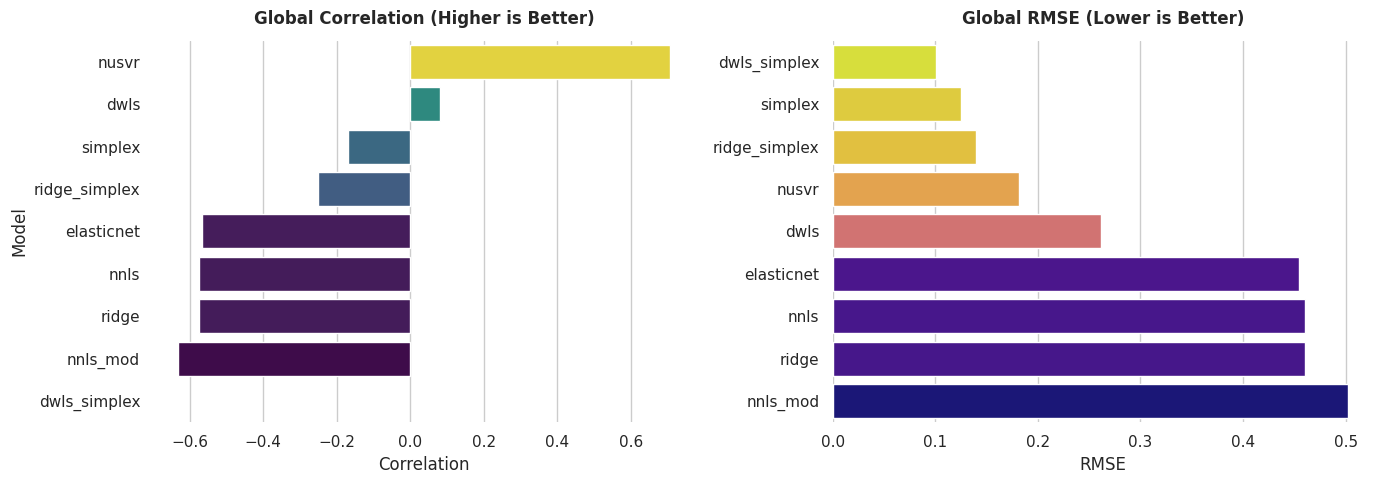

In [72]:
plot_solver_benchmarks(results, ground_truth)